In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

In [5]:
# load dataset
df = pd.read_csv("energy_data.csv")
df.head()

,timestamp,location,energy_consumption,temperature
0,01-01-2023 00:00,Industrial,139.101364,33.820542
1,01-01-2023 01:00,Residential,247.109808,26.392602
2,01-01-2023 02:00,Industrial,233.934693,25.027439
3,01-01-2023 03:00,Industrial,243.013532,27.107712
4,01-01-2023 04:00,Residential,313.502582,27.326153


In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
df = df.dropna()
df = df.set_index("timestamp")
df.head()

,location,energy_consumption,temperature
timestamp,,,
2023-01-01 00:00:00,Industrial,139.101364,33.820542
2023-01-01 01:00:00,Residential,247.109808,26.392602
2023-01-01 02:00:00,Industrial,233.934693,25.027439
2023-01-01 03:00:00,Industrial,243.013532,27.107712
2023-01-01 04:00:00,Residential,313.502582,27.326153


In [7]:
X = df[["energy_consumption", "temperature"]]

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

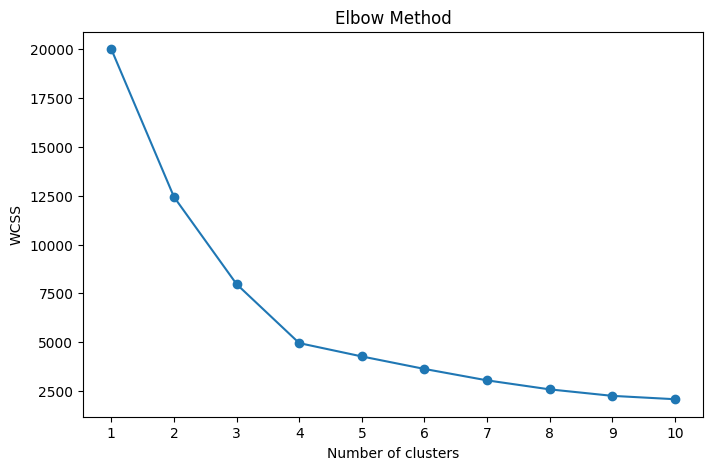

In [9]:
# elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
# plotting elbow method
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker = 'o', linestyle='-')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.show()


In [10]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [11]:
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(X_scaled, df['cluster'])
print(f'Silhouette Score: {silhouette_avg}')

Silhouette Score: 0.3742803579579692


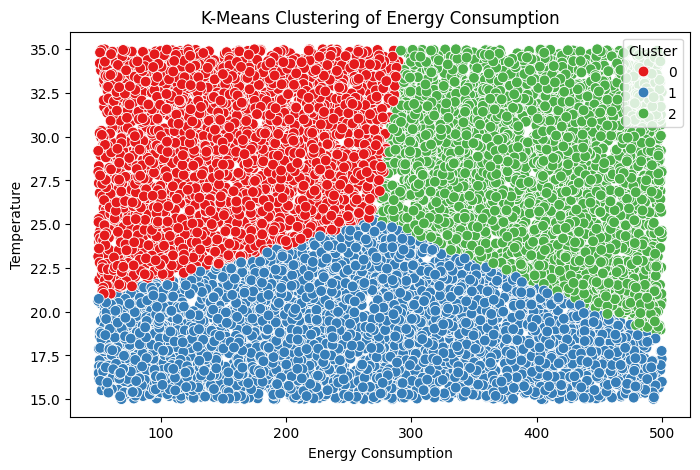

In [12]:
# visualization
plt.figure(figsize=(8, 5))
sns.scatterplot(x='energy_consumption', y='temperature', hue='cluster', data=df, palette='Set1', s=60)
plt.title('K-Means Clustering of Energy Consumption')
plt.xlabel('Energy Consumption')
plt.ylabel('Temperature')
plt.legend(title='Cluster')
plt.show()

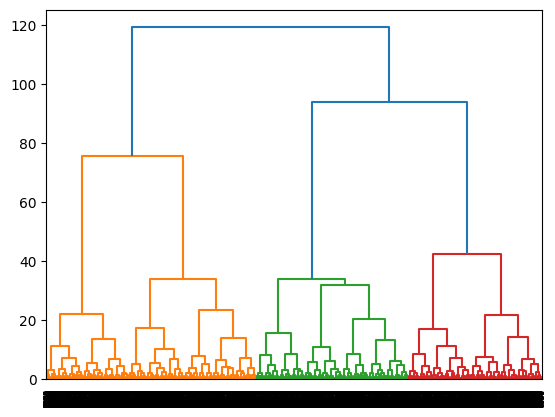

In [13]:
link = sch.linkage(X_scaled, method='ward')
dend = sch.dendrogram(link)

In [14]:
models = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
label = models.fit_predict(X_scaled)
label

array([4, 2, 2, ..., 2, 4, 0], shape=(10000,))

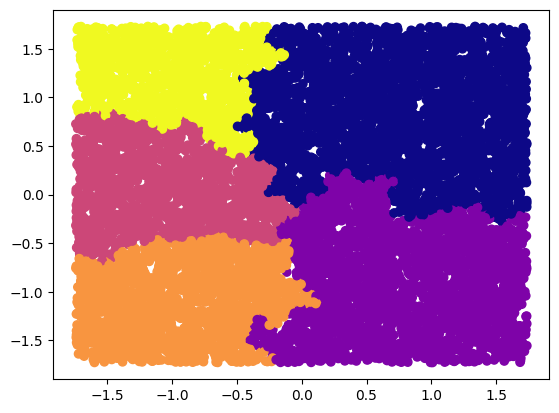

In [16]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=label, cmap='plasma')

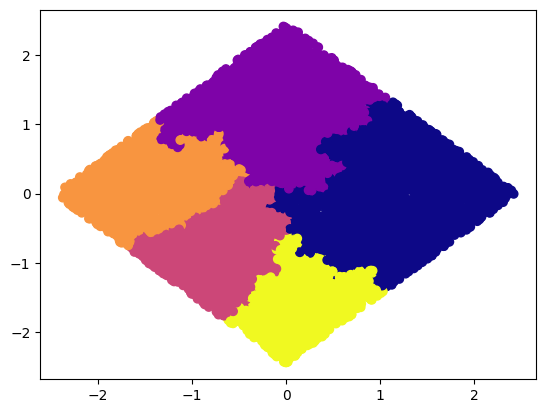

In [17]:
# pca for visualization
pca = PCA(n_components=2)
X_new = pca.fit_transform(X_scaled)
plt.scatter(X_new[:, 0], X_new[:, 1], c=label, cmap ='plasma')
plt.show()